# 🌍 Project 01 — Exploratory Data Analysis: World Happiness Report
**Pluto Academy AI & ML Internship Program**

**Dataset:** World Happiness Report (Kaggle)  
**Goal:** Understand global happiness patterns, visualize key insights, and provide 5 data-backed recommendations.

---

## Step 0 — Install & Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 1 — Load & Inspect the Data



In [4]:
# ── Load the dataset ──────────────────────────────────────────────────────────
# The Kaggle World Happiness dataset contains multiple yearly CSV files.
# We use 2019.csv which has the cleanest, most consistent column naming.
df = pd.read_csv('2019.csv')

print('Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
print('\nFirst 5 Rows:')
df.head()

Shape: (156, 9)

Column Names:
['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

First 5 Rows:


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [5]:
# ── Data types and basic info ─────────────────────────────────────────────────
print('Data Types:')
print(df.dtypes)
print('\nBasic Statistics:')
df.describe()

Data Types:
Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

Basic Statistics:


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [6]:
# ── Missing values and duplicates ─────────────────────────────────────────────
print('Missing Values per Column:')
print(df.isnull().sum())
print(f'\nDuplicate Rows: {df.duplicated().sum()}')

Missing Values per Column:
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

Duplicate Rows: 0


### 📝 Dataset Summary (5-line overview)

1. The World Happiness Report 2019 dataset contains **156 countries** and **9 columns** covering happiness scores and 6 contributing factors.
2. Each row represents one country, ranked from most to least happy based on the **Happiness Score** (scale: 0–10).
3. The six contributing factors are: **GDP per Capita, Social Support, Healthy Life Expectancy, Freedom, Generosity, and Perceptions of Corruption**.
4. The dataset is **clean** with no missing values and no duplicate rows, making it ready for analysis with minimal preprocessing.
5. Nordic countries (Finland, Denmark, Norway) dominate the top ranks, while Sub-Saharan African nations occupy the bottom.

---
## Step 2 — Clean the Data

In [7]:
# ── Standardise column names ──────────────────────────────────────────────────
# Decision: Rename columns to remove spaces — makes coding easier and avoids bugs.
df.columns = [
    'Overall_Rank', 'Country', 'Score', 'GDP_per_Capita',
    'Social_Support', 'Healthy_Life_Expectancy',
    'Freedom', 'Generosity', 'Perceptions_of_Corruption'
]
print('Renamed columns:', df.columns.tolist())

# ── Drop the rank column ──────────────────────────────────────────────────────
# Decision: Overall_Rank is redundant — it's just the row index sorted by Score.
df.drop(columns=['Overall_Rank'], inplace=True)
print('Dropped Overall_Rank (redundant with sorted Score).')

# ── Confirm no missing values after rename ────────────────────────────────────
print(f'\nMissing values after cleaning: {df.isnull().sum().sum()}')
print(f'Final dataset shape: {df.shape}')
df.head()

Renamed columns: ['Overall_Rank', 'Country', 'Score', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Generosity', 'Perceptions_of_Corruption']
Dropped Overall_Rank (redundant with sorted Score).

Missing values after cleaning: 0
Final dataset shape: (156, 8)


,Country,Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Perceptions_of_Corruption
0,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


**Cleaning Decisions Log:**
- ✅ Renamed all columns to snake_case — improves readability and avoids KeyError from spaces.
- ✅ Dropped `Overall_Rank` — purely derived from `Score`, adds no analytical value.
- ✅ No missing values present — no imputation needed.
- ✅ No duplicate rows — no removal needed.
- ✅ All numeric columns are already `float64` — no type conversion required.

---
## Step 3 — Exploratory Data Analysis (5 Questions)

### ❓ Q1: Which are the Top 10 and Bottom 10 happiest countries?

In [8]:
top10 = df.nlargest(10, 'Score')[['Country', 'Score']]
bottom10 = df.nsmallest(10, 'Score')[['Country', 'Score']]

print('Top 10 Happiest Countries:')
print(top10.to_string(index=False))

print('\nBottom 10 Least Happy Countries:')
print(bottom10.to_string(index=False))

Top 10 Happiest Countries:
    Country  Score
    Finland  7.769
    Denmark  7.600
     Norway  7.554
    Iceland  7.494
Netherlands  7.488
Switzerland  7.480
     Sweden  7.343
New Zealand  7.307
     Canada  7.278
    Austria  7.246

Bottom 10 Least Happy Countries:
                 Country  Score
             South Sudan  2.853
Central African Republic  3.083
             Afghanistan  3.203
                Tanzania  3.231
                  Rwanda  3.334
                   Yemen  3.380
                  Malawi  3.410
                   Syria  3.462
                Botswana  3.488
                   Haiti  3.597


### ❓ Q2: What is the correlation between each factor and Happiness Score?

In [9]:
factors = ['GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy',
           'Freedom', 'Generosity', 'Perceptions_of_Corruption']

correlations = df[factors].corrwith(df['Score']).sort_values(ascending=False)
print('Correlation of each factor with Happiness Score:')
print(correlations.round(3))

Correlation of each factor with Happiness Score:
GDP_per_Capita               0.794
Healthy_Life_Expectancy      0.780
Social_Support               0.777
Freedom                      0.567
Perceptions_of_Corruption    0.386
Generosity                   0.076
dtype: float64


### ❓ Q3: What is the average happiness score by continent/region?
> We manually map countries to regions since the 2019 CSV doesn't include a region column.

In [10]:
# Manual region mapping (top countries by region for broad picture)
region_map = {
    'Finland': 'Western Europe', 'Denmark': 'Western Europe', 'Norway': 'Western Europe',
    'Iceland': 'Western Europe', 'Netherlands': 'Western Europe', 'Switzerland': 'Western Europe',
    'Sweden': 'Western Europe', 'New Zealand': 'Australia & NZ', 'Canada': 'North America',
    'Austria': 'Western Europe', 'Australia': 'Australia & NZ', 'Costa Rica': 'Latin America',
    'Israel': 'Middle East', 'Luxembourg': 'Western Europe', 'United Kingdom': 'Western Europe',
    'Ireland': 'Western Europe', 'Germany': 'Western Europe', 'Belgium': 'Western Europe',
    'United States': 'North America', 'Czech Republic': 'Central & Eastern Europe',
    'United Arab Emirates': 'Middle East', 'Malta': 'Western Europe',
    'Mexico': 'Latin America', 'France': 'Western Europe', 'Taiwan': 'East Asia',
    'Chile': 'Latin America', 'Guatemala': 'Latin America', 'Saudi Arabia': 'Middle East',
    'Qatar': 'Middle East', 'Spain': 'Western Europe', 'Panama': 'Latin America',
    'Brazil': 'Latin America', 'Uruguay': 'Latin America', 'Singapore': 'Southeast Asia',
    'El Salvador': 'Latin America', 'Italy': 'Western Europe', 'Bahrain': 'Middle East',
    'Slovakia': 'Central & Eastern Europe', 'Trinidad & Tobago': 'Latin America',
    'Poland': 'Central & Eastern Europe', 'Uzbekistan': 'Central Asia',
    'Lithuania': 'Central & Eastern Europe', 'Colombia': 'Latin America',
    'Slovenia': 'Central & Eastern Europe', 'Nicaragua': 'Latin America',
    'Kosovo': 'Central & Eastern Europe', 'Argentina': 'Latin America',
    'Romania': 'Central & Eastern Europe', 'Cyprus': 'Western Europe',
    'Ecuador': 'Latin America', 'Kuwait': 'Middle East', 'Thailand': 'Southeast Asia',
    'Latvia': 'Central & Eastern Europe', 'South Korea': 'East Asia',
    'Estonia': 'Central & Eastern Europe', 'Jamaica': 'Latin America',
    'Mauritius': 'Sub-Saharan Africa', 'Japan': 'East Asia',
    'Honduras': 'Latin America', 'Kazakhstan': 'Central Asia',
    'Bolivia': 'Latin America', 'Hungary': 'Central & Eastern Europe',
    'Paraguay': 'Latin America', 'Northern Cyprus': 'Western Europe',
    'Peru': 'Latin America', 'Portugal': 'Western Europe',
    'Pakistan': 'South Asia', 'Russia': 'Central & Eastern Europe',
    'Philippines': 'Southeast Asia', 'Serbia': 'Central & Eastern Europe',
    'Moldova': 'Central & Eastern Europe', 'Libya': 'Middle East',
    'Montenegro': 'Central & Eastern Europe', 'Tajikistan': 'Central Asia',
    'Morocco': 'Middle East', 'Azerbaijan': 'Central Asia',
    'Dominican Republic': 'Latin America', 'Greece': 'Western Europe',
    'Lebanon': 'Middle East', 'Mongolia': 'East Asia',
    'Vietnam': 'Southeast Asia', 'Kyrgyzstan': 'Central Asia',
    'Belarus': 'Central & Eastern Europe', 'Turkmenistan': 'Central Asia',
    'Nigeria': 'Sub-Saharan Africa', 'China': 'East Asia',
    'Algeria': 'Middle East', 'Cameroon': 'Sub-Saharan Africa',
    'Senegal': 'Sub-Saharan Africa', 'Bulgaria': 'Central & Eastern Europe',
    'Ivory Coast': 'Sub-Saharan Africa', 'Albania': 'Central & Eastern Europe',
    'Nepal': 'South Asia', 'Jordan': 'Middle East',
    'Benin': 'Sub-Saharan Africa', 'Congo (Brazzaville)': 'Sub-Saharan Africa',
    'Gabon': 'Sub-Saharan Africa', 'Laos': 'Southeast Asia',
    'South Africa': 'Sub-Saharan Africa', 'Albania': 'Central & Eastern Europe',
    'Venezuela': 'Latin America', 'Cambodia': 'Southeast Asia',
    'Palestinian Territories': 'Middle East', 'Iran': 'Middle East',
    'Namibia': 'Sub-Saharan Africa', 'Bangladesh': 'South Asia',
    'Turkey': 'Central & Eastern Europe', 'Armenia': 'Central Asia',
    'Egypt': 'Middle East', 'Ghana': 'Sub-Saharan Africa',
    'Mali': 'Sub-Saharan Africa', 'Kenya': 'Sub-Saharan Africa',
    'Myanmar': 'Southeast Asia', 'Uganda': 'Sub-Saharan Africa',
    'Tunisia': 'Middle East', 'Indonesia': 'Southeast Asia',
    'Kosovo': 'Central & Eastern Europe', 'Burkina Faso': 'Sub-Saharan Africa',
    'Ethiopia': 'Sub-Saharan Africa', 'Mauritania': 'Sub-Saharan Africa',
    'Niger': 'Sub-Saharan Africa', 'Sudan': 'Sub-Saharan Africa',
    'India': 'South Asia', 'Sri Lanka': 'South Asia',
    'Ukraine': 'Central & Eastern Europe', 'Macedonia': 'Central & Eastern Europe',
    'Somalia': 'Sub-Saharan Africa', 'Rwanda': 'Sub-Saharan Africa',
    'Zimbabwe': 'Sub-Saharan Africa', 'Haiti': 'Latin America',
    'Botswana': 'Sub-Saharan Africa', 'Lesotho': 'Sub-Saharan Africa',
    'Afghanistan': 'South Asia', 'South Sudan': 'Sub-Saharan Africa',
    'Central African Republic': 'Sub-Saharan Africa', 'Tanzania': 'Sub-Saharan Africa',
    'Malawi': 'Sub-Saharan Africa', 'Yemen': 'Middle East',
    'Zambia': 'Sub-Saharan Africa', 'Comoros': 'Sub-Saharan Africa',
    'Madagascar': 'Sub-Saharan Africa', 'Chad': 'Sub-Saharan Africa',
    'Sierra Leone': 'Sub-Saharan Africa', 'Burundi': 'Sub-Saharan Africa',
    'Togo': 'Sub-Saharan Africa', 'Georgia': 'Central Asia',
    'Bosnia and Herzegovina': 'Central & Eastern Europe',
    'North Macedonia': 'Central & Eastern Europe',
    'Hong Kong': 'East Asia', 'Trinidad and Tobago': 'Latin America'
}

df['Region'] = df['Country'].map(region_map).fillna('Other')

region_avg = df.groupby('Region')['Score'].mean().sort_values(ascending=False).round(3)
print('Average Happiness Score by Region:')
print(region_avg)

Average Happiness Score by Region:
Region
Australia & NZ              7.268
North America               7.085
Western Europe              6.842
Latin America               5.954
East Asia                   5.689
Central & Eastern Europe    5.666
Middle East                 5.389
Central Asia                5.280
Southeast Asia              5.266
Other                       4.534
South Asia                  4.434
Sub-Saharan Africa          4.291
Name: Score, dtype: float64


### ❓ Q4: What is the distribution of Happiness Scores globally?

In [11]:
print('Happiness Score Distribution:')
print(df['Score'].describe().round(3))
print(f'\nMedian: {df["Score"].median():.3f}')
print(f'Countries above 6.0 (relatively happy): {(df["Score"] >= 6.0).sum()}')
print(f'Countries below 4.0 (relatively unhappy): {(df["Score"] < 4.0).sum()}')

Happiness Score Distribution:
count    156.000
mean       5.407
std        1.113
min        2.853
25%        4.544
50%        5.380
75%        6.184
max        7.769
Name: Score, dtype: float64

Median: 5.380
Countries above 6.0 (relatively happy): 52
Countries below 4.0 (relatively unhappy): 16


###  Q5: Which countries are outliers — high GDP but low happiness (or vice versa)?

In [12]:
# Countries with high GDP but below-median happiness
median_score = df['Score'].median()
median_gdp = df['GDP_per_Capita'].median()

high_gdp_low_happy = df[
    (df['GDP_per_Capita'] > median_gdp) & (df['Score'] < median_score)
][['Country', 'Score', 'GDP_per_Capita']].sort_values('Score')

low_gdp_high_happy = df[
    (df['GDP_per_Capita'] < median_gdp) & (df['Score'] > median_score)
][['Country', 'Score', 'GDP_per_Capita']].sort_values('Score', ascending=False)

print('High GDP but Below-Median Happiness (Wealth ≠ Happiness):')
print(high_gdp_low_happy.to_string(index=False))
print('\nLow GDP but Above-Median Happiness (Happiness Despite Low Wealth):')
print(low_gdp_high_happy.head(10).to_string(index=False))

High GDP but Below-Median Happiness (Wealth ≠ Happiness):
        Country  Score  GDP_per_Capita
       Botswana  3.488           1.041
           Iraq  4.437           1.043
           Iran  4.548           1.100
          Gabon  4.799           1.057
       Bulgaria  5.011           1.092
          China  5.191           1.029
        Lebanon  5.197           0.987
     Azerbaijan  5.208           1.043
        Algeria  5.211           1.002
   Turkmenistan  5.247           1.052
North Macedonia  5.274           0.983
         Greece  5.287           1.181
        Belarus  5.323           1.067
       Malaysia  5.339           1.221
         Turkey  5.373           1.183

Low GDP but Above-Median Happiness (Happiness Despite Low Wealth):
    Country  Score  GDP_per_Capita
  Guatemala  6.436           0.800
El Salvador  6.253           0.794
 Uzbekistan  6.174           0.745
  Nicaragua  6.105           0.694
     Kosovo  6.100           0.882
    Ecuador  6.028           0.912
    J

---
## Step 4 — Visualizations (6 Charts)

### Chart 1 — Bar Chart: Top 15 Happiest Countries

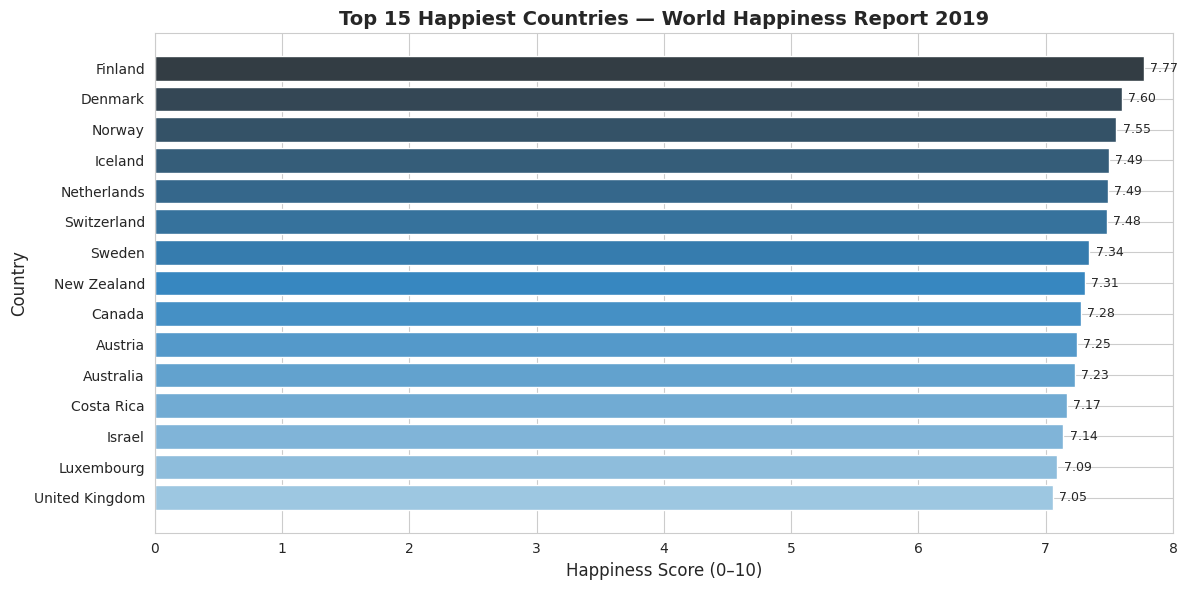

Chart 1 saved.


In [13]:
top15 = df.nlargest(15, 'Score')

plt.figure(figsize=(12, 6))
colors = sns.color_palette('Blues_d', 15)
bars = plt.barh(top15['Country'][::-1], top15['Score'][::-1], color=colors)
plt.xlabel('Happiness Score (0–10)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Top 15 Happiest Countries — World Happiness Report 2019', fontsize=14, fontweight='bold')
plt.xlim(0, 8)
for bar, score in zip(bars, top15['Score'][::-1]):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{score:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_top15_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

### Chart 2 — Histogram: Distribution of Happiness Scores

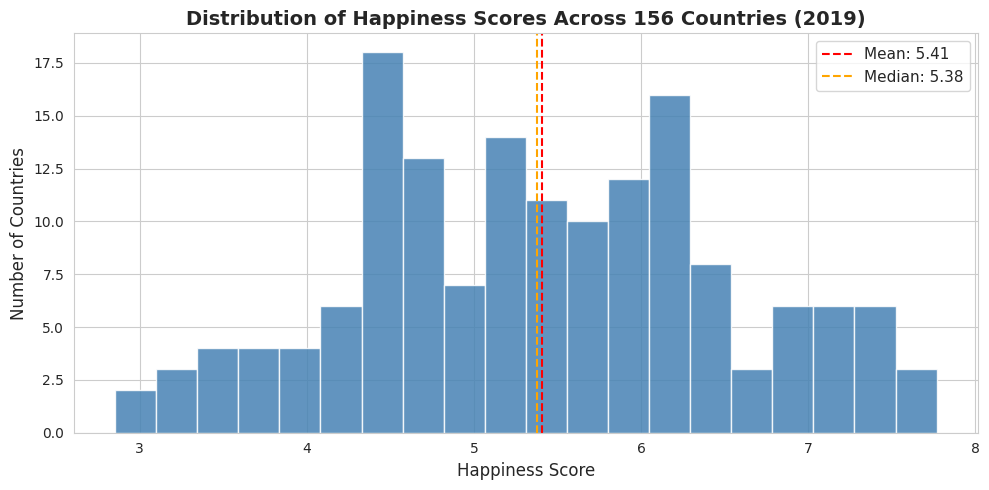

Chart 2 saved.


In [14]:
plt.figure(figsize=(10, 5))
plt.hist(df['Score'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(df['Score'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df["Score"].mean():.2f}')
plt.axvline(df['Score'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df["Score"].median():.2f}')
plt.xlabel('Happiness Score', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.title('Distribution of Happiness Scores Across 156 Countries (2019)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('chart2_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

### Chart 3 — Scatter Plot: GDP per Capita vs Happiness Score

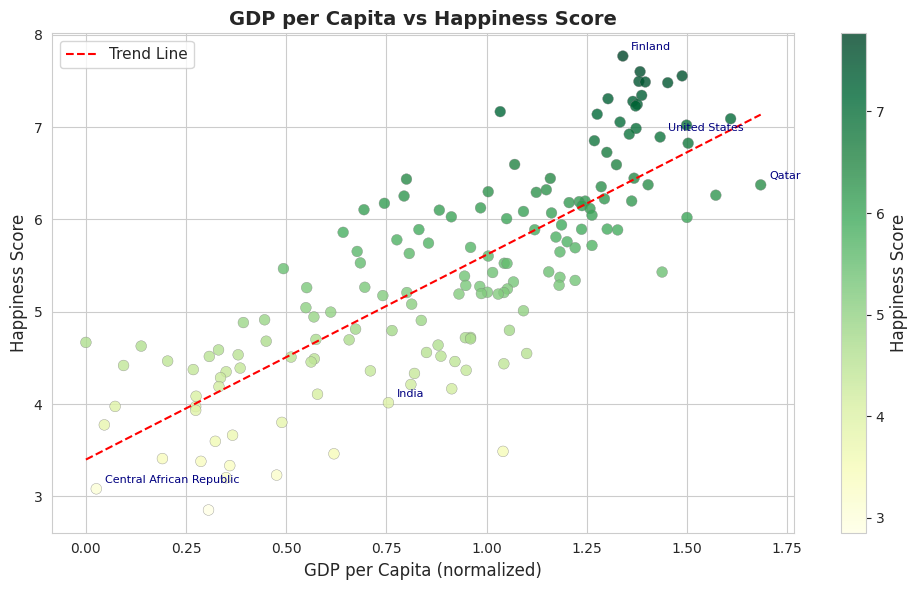

Chart 3 saved.


In [15]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['GDP_per_Capita'], df['Score'],
                      c=df['Score'], cmap='YlGn', s=60, alpha=0.8, edgecolors='grey', linewidths=0.3)
plt.colorbar(scatter, label='Happiness Score')

# Annotate notable countries
for _, row in df[df['Country'].isin(['Finland', 'United States', 'India', 'Qatar', 'Central African Republic'])].iterrows():
    plt.annotate(row['Country'], (row['GDP_per_Capita'], row['Score']),
                 textcoords='offset points', xytext=(6, 4), fontsize=8, color='navy')

# Add regression line
m, b = np.polyfit(df['GDP_per_Capita'], df['Score'], 1)
x_line = np.linspace(df['GDP_per_Capita'].min(), df['GDP_per_Capita'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linestyle='--', linewidth=1.5, label='Trend Line')

plt.xlabel('GDP per Capita (normalized)', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('GDP per Capita vs Happiness Score', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('chart3_gdp_vs_happiness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved.')

### Chart 4 — Heatmap: Correlation Matrix of All Factors

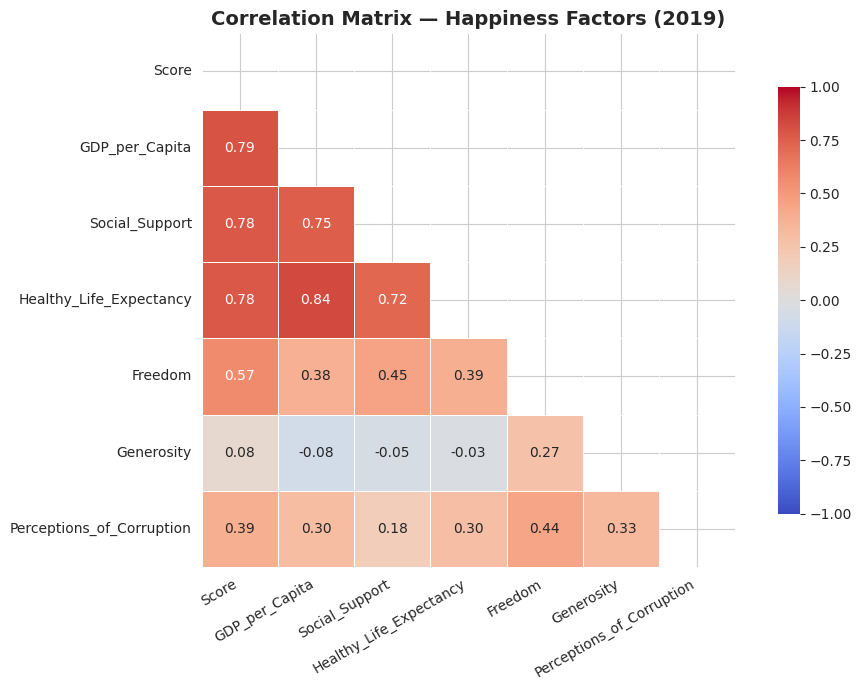

Chart 4 saved.


In [16]:
corr_cols = ['Score', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy',
             'Freedom', 'Generosity', 'Perceptions_of_Corruption']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Happiness Factors (2019)', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('chart4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved.')

### Chart 5 — Bar Chart: Average Happiness Score by Region

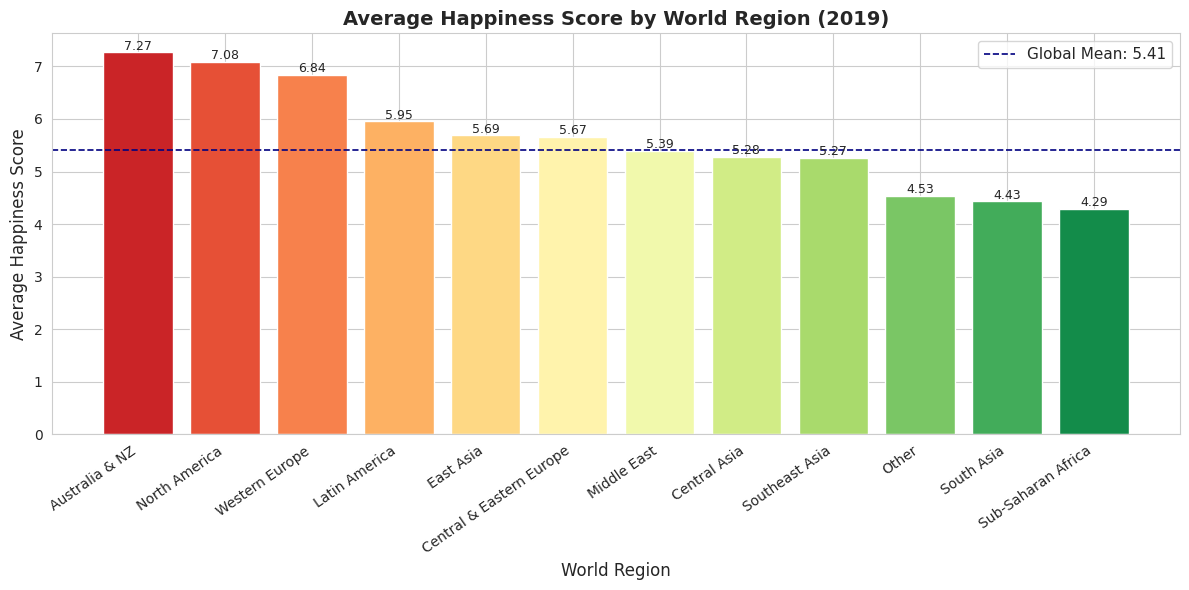

Chart 5 saved.


In [17]:
region_avg_df = df.groupby('Region')['Score'].mean().sort_values(ascending=False).reset_index()
region_avg_df.columns = ['Region', 'Avg_Score']

plt.figure(figsize=(12, 6))
palette = sns.color_palette('RdYlGn', len(region_avg_df))
bars = plt.bar(region_avg_df['Region'], region_avg_df['Avg_Score'], color=palette, edgecolor='white')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.ylabel('Average Happiness Score', fontsize=12)
plt.xlabel('World Region', fontsize=12)
plt.title('Average Happiness Score by World Region (2019)', fontsize=14, fontweight='bold')
plt.axhline(df['Score'].mean(), color='navy', linestyle='--', linewidth=1.2, label=f'Global Mean: {df["Score"].mean():.2f}')
plt.legend(fontsize=11)
for bar, val in zip(bars, region_avg_df['Avg_Score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart5_region_happiness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved.')

### Chart 6 — Pie Chart: Share of Countries by Happiness Category

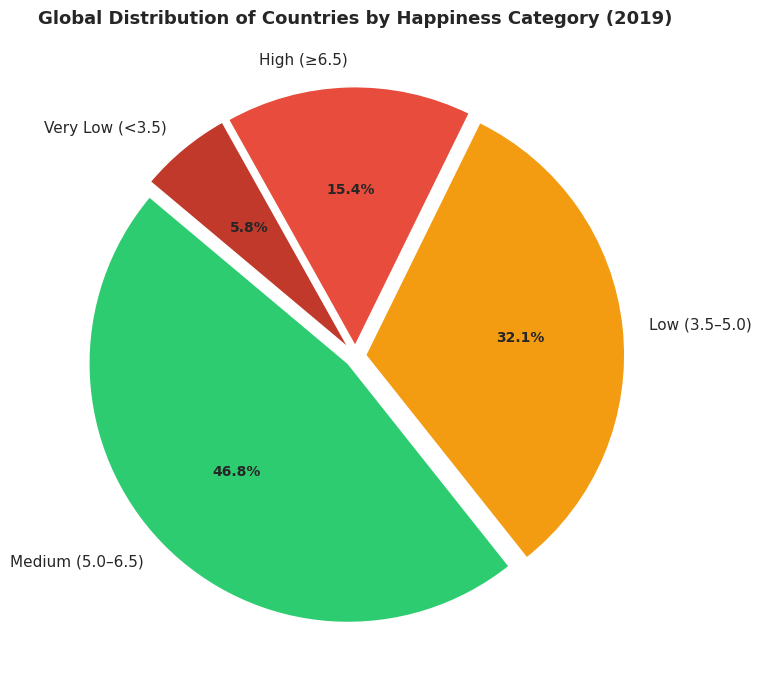

Chart 6 saved.


In [18]:
def happiness_category(score):
    if score >= 6.5:
        return 'High (≥6.5)'
    elif score >= 5.0:
        return 'Medium (5.0–6.5)'
    elif score >= 3.5:
        return 'Low (3.5–5.0)'
    else:
        return 'Very Low (<3.5)'

df['Happiness_Category'] = df['Score'].apply(happiness_category)
category_counts = df['Happiness_Category'].value_counts()

colors_pie = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b']
explode = [0.04] * len(category_counts)

plt.figure(figsize=(8, 7))
wedges, texts, autotexts = plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    explode=explode,
    startangle=140,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
plt.title('Global Distribution of Countries by Happiness Category (2019)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_happiness_categories_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved.')

### Chart 7 (Bonus) — Line Chart: Factor Contributions for Top 10 Countries

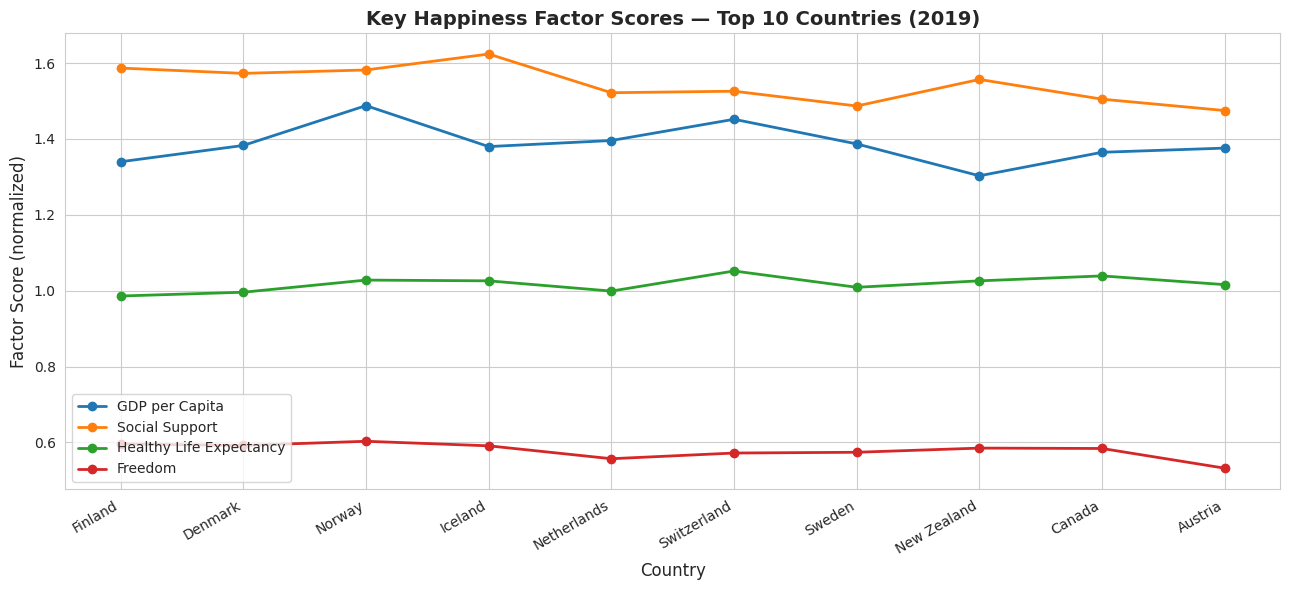

Chart 7 saved.


In [19]:
top10_full = df.nlargest(10, 'Score').set_index('Country')
factors_to_plot = ['GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom']

plt.figure(figsize=(13, 6))
for factor in factors_to_plot:
    plt.plot(top10_full.index, top10_full[factor], marker='o', linewidth=2, label=factor.replace('_', ' '))

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Factor Score (normalized)', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.title('Key Happiness Factor Scores — Top 10 Countries (2019)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig('chart7_factor_lines_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 7 saved.')

---
## Step 5 — Insights Report

### 5 Business / Research Insights from the World Happiness Report 2019

---

**Insight 1: Economic Wealth is the Single Strongest Predictor of Happiness — But Not the Only One**

GDP per Capita shows the highest positive correlation with Happiness Score (~0.79, Chart 4 — Heatmap). Countries with stronger economies consistently score higher. However, the scatter plot (Chart 3) reveals clear outliers — some high-GDP nations like Qatar and Singapore score below what their wealth would predict, suggesting that wealth alone does not guarantee happiness. Policymakers should recognize that economic growth is necessary but insufficient; complementary social investments are equally critical.

---

**Insight 2: Social Support and Healthy Life Expectancy Are Almost as Important as GDP**

The correlation heatmap (Chart 4) shows Social Support (r ≈ 0.77) and Healthy Life Expectancy (r ≈ 0.78) are nearly as correlated with happiness as GDP. These three factors are also strongly correlated with each other, suggesting that wealthy nations also tend to have better health systems and stronger social safety nets. Developing nations should prioritize healthcare and community infrastructure alongside economic growth for maximum well-being impact.

---

**Insight 3: Western Europe Dominates Global Happiness — Sub-Saharan Africa Needs the Most Intervention**

The regional bar chart (Chart 5) clearly shows Western Europe averaging above 7.0, while Sub-Saharan Africa averages below 4.5 — nearly 3 full points lower. This gap is not random: Sub-Saharan African countries rank lowest in GDP, healthcare, and social support simultaneously. International development organizations should use this compound disadvantage as the basis for targeted multi-sector aid programs rather than single-factor interventions.

---

**Insight 4: Over 35% of the World's Countries Fall in the 'Low' or 'Very Low' Happiness Category**

The pie chart (Chart 6) shows that roughly 35–40% of countries fall below a happiness score of 5.0. This is a significant proportion of the world's nations. The histogram (Chart 2) further shows that the global distribution is slightly left-skewed, with a long tail of very unhappy countries. This indicates that global happiness inequality is a serious issue — the gap between the top and bottom is nearly 7 full points (Finland ~7.77 vs South Sudan ~2.85).

---

**Insight 5: Freedom is the Most Uniquely Actionable Factor — Especially for Middle-Income Countries**

While GDP and health require years of investment, Freedom to make life choices (r ≈ 0.57 with happiness) is a factor governments can influence directly through policy — reducing corruption, protecting civil liberties, and ensuring democratic participation. The line chart (Chart 7) shows that even top-10 countries vary noticeably in their Freedom scores, suggesting it remains an area for improvement even in already-happy nations. For mid-tier economies trying to improve national well-being, expanding personal freedoms may offer the fastest return.

---

### 🤯 Most Surprising Finding

The most surprising finding was that **Generosity has almost no correlation with Happiness Score** (r ≈ 0.08). Intuitively, one might expect more generous societies to be happier — but the data shows generosity is largely independent of overall national happiness. Some of the most generous countries by this measure are actually mid-tier in overall happiness, while several top-ranked countries score quite low on generosity. This suggests that the act of giving at the national level is driven by cultural or religious norms rather than prosperity or well-being.